<a href="https://colab.research.google.com/github/JoudySaleh-IT/IT461-MovieGenreClassification/blob/main/Movie_Genre_Classification_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Genre Classification from Plot Summaries
### IT461 Practical Machine Learning Project
This notebook presents an end-to-end workflow for movie genre classification using textual plot summaries.

In [2]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

import joblib

# 1. Check Available Files
In this section, we verify that the required dataset files are available in the working directory.

In [3]:
!ls -lh

total 6.1M
-rw-r--r-- 1 root root  366 May  8 01:11 description.txt
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data
-rw-r--r-- 1 root root 2.0M May  8 01:11 test_data_solution.txt
-rw-r--r-- 1 root root 2.0M May  8 01:11 test_data.txt
-rw-r--r-- 1 root root 2.0M May  8 01:11 train_data.txt


# 2. Preview Raw Training Data
Before loading the dataset formally, we inspect a few raw lines to understand the original file format.

In [4]:
with open("train_data.txt", "r", encoding="latin-1") as f:
    for i in range(5):
        print(repr(f.readline()))

'1 ::: Oscar et la dame rose (2009) ::: drama ::: Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.\n'
'2 ::: Cupid (1997) ::: thriller ::: A brother and sister with a past incestuous relationship have a current murderous relationship. He murders the women who reject him and she murders the women who get too close to him.\n'
'3 ::: Young, Wild and Wonderful (1980) ::: adult ::: As the bus empties the students for their field trip to the Museum of Natural History, little does the tour guide suspect t

# 3. Define Data Loading Functions
These helper functions read the training, test, and test solution files and convert them into pandas DataFrames.

In [5]:
def load_train_data(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=3)
            if len(parts) == 4:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Title", "Genre", "Description"])


def load_test_data(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=2)
            if len(parts) == 3:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Title", "Description"])


def load_test_solution(file_path):
    rows = []
    with open(file_path, "r", encoding="latin-1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = re.split(r"\s*:::\s*", line, maxsplit=1)
            if len(parts) == 2:
                rows.append(parts)
    return pd.DataFrame(rows, columns=["ID", "Genre"])

# 4. Load the Dataset
We now load the training, test, and test-solution files into DataFrames.

In [6]:
train_df = load_train_data("train_data.txt")
test_df = load_test_data("test_data.txt")
test_solution_df = load_test_solution("test_data_solution.txt")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test solution shape:", test_solution_df.shape)

Train shape: (3178, 4)
Test shape: (3260, 3)
Test solution shape: (3202, 2)


# 5. Inspect the Training Data
We inspect the first few rows to understand the dataset structure and verify that it was loaded correctly.

In [7]:
train_df.head()

,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


# 6. Dataset Information and Missing Values
This section shows the data types, missing values, and the number of unique genre classes.

In [8]:
print(train_df.info())
print("\nMissing values:\n", train_df.isnull().sum())
print("\nNumber of unique genres:", train_df["Genre"].nunique())
print("\nGenres:\n", sorted(train_df["Genre"].unique()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3178 entries, 0 to 3177
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           3178 non-null   object
 1   Title        3178 non-null   object
 2   Genre        3178 non-null   object
 3   Description  3178 non-null   object
dtypes: object(4)
memory usage: 99.4+ KB
None

Missing values:
 ID             0
Title          0
Genre          0
Description    0
dtype: int64

Number of unique genres: 27

Genres:
 ['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']


# 7. Summary Statistics
To better understand the dataset, we present key summary statistics describing its structure and scale.

In [9]:
summary_stats = pd.DataFrame({
    "Attribute": [
        "Task Type",
        "Number of Training Examples",
        "Number of Test Examples",
        "Number of Classes (Genres)",
        "Input Feature Type",
        "Output Label"
    ],
    "Value": [
        "Multi-class text classification",
        len(train_df),
        len(test_df),
        train_df["Genre"].nunique(),
        "Text (movie plot summary)",
        "Single genre"
    ]
})

summary_stats

,Attribute,Value
0,Task Type,Multi-class text classification
1,Number of Training Examples,3178
2,Number of Test Examples,3260
3,Number of Classes (Genres),27
4,Input Feature Type,Text (movie plot summary)
5,Output Label,Single genre


# 8. Representative Examples
Below are a few representative examples from the training dataset, including movie title, genre, and description.

In [10]:
train_df[["Title", "Genre", "Description"]].head(5)

,Title,Genre,Description
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


# 9. Text Preprocessing Function
Since machine learning models cannot process raw text directly, we define a cleaning function to normalize the descriptions.

In [11]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 10. Apply Text Preprocessing
We apply the preprocessing function to both the training and test descriptions.

In [12]:
train_df["Clean_Title"] = train_df["Title"].apply(clean_text)
train_df["Clean_Description"] = train_df["Description"].apply(clean_text)

test_df["Clean_Title"] = test_df["Title"].apply(clean_text)
test_df["Clean_Description"] = test_df["Description"].apply(clean_text)

train_df["Full_Text"] = train_df["Clean_Title"] + " " + train_df["Clean_Description"]
test_df["Full_Text"] = test_df["Clean_Title"] + " " + test_df["Clean_Description"]

train_df[["Title", "Clean_Title", "Description", "Clean_Description", "Full_Text"]].head()

,Title,Clean_Title,Description,Clean_Description,Full_Text
0,Oscar et la dame rose (2009),oscar et la dame rose,Listening in to a conversation between his doc...,listening in to a conversation between his doc...,oscar et la dame rose listening in to a conver...
1,Cupid (1997),cupid,A brother and sister with a past incestuous re...,a brother and sister with a past incestuous re...,cupid a brother and sister with a past incestu...
2,"Young, Wild and Wonderful (1980)",young wild and wonderful,As the bus empties the students for their fiel...,as the bus empties the students for their fiel...,young wild and wonderful as the bus empties th...
3,The Secret Sin (1915),the secret sin,To help their unemployed father make ends meet...,to help their unemployed father make ends meet...,the secret sin to help their unemployed father...
4,The Unrecovered (2007),the unrecovered,The film's title refers not only to the un-rec...,the films title refers not only to the unrecov...,the unrecovered the films title refers not onl...


# 11. Analyze Description Lengths
We examine the distribution of movie description lengths to better understand variation in input size.

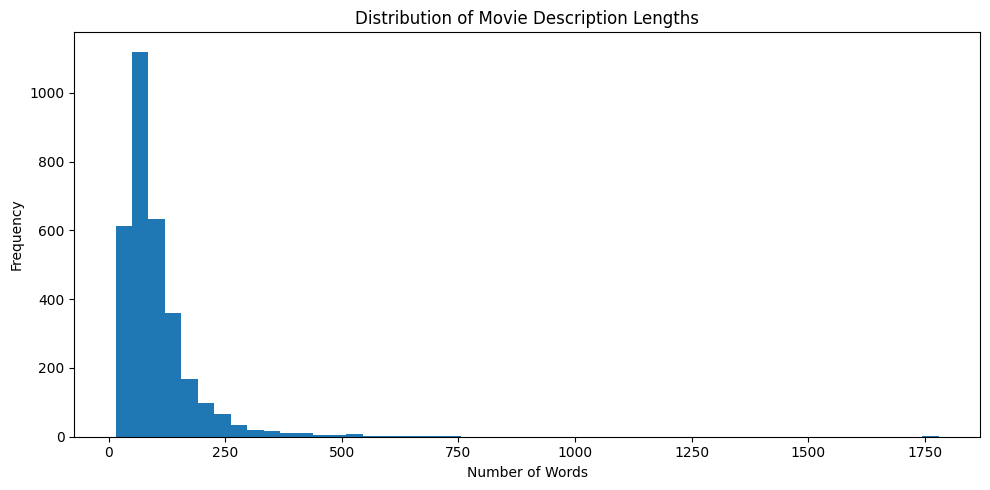

In [13]:
train_df["desc_length"] = train_df["Clean_Description"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
plt.hist(train_df["desc_length"], bins=50)
plt.title("Distribution of Movie Description Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 12. Class Distribution Analysis
This plot shows the distribution of genre classes in the training set and highlights possible class imbalance.

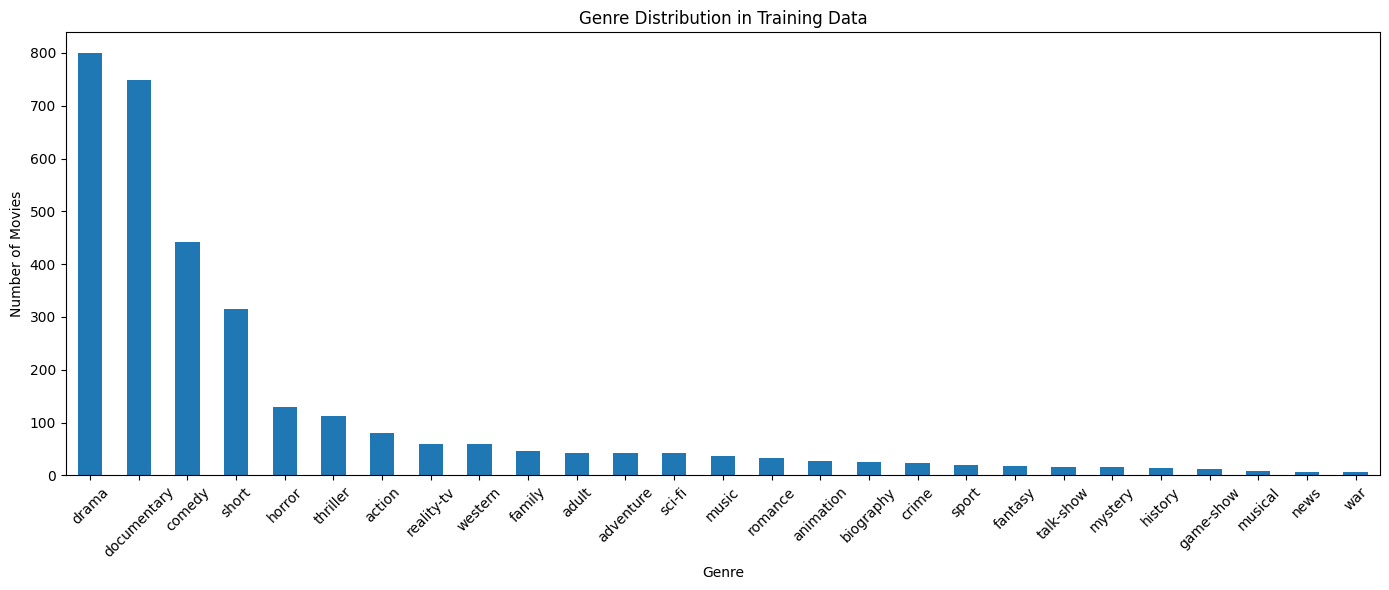

In [14]:
plt.figure(figsize=(14,6))
train_df["Genre"].value_counts().plot(kind="bar")
plt.title("Genre Distribution in Training Data")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Most Common Words in Plot Summaries')

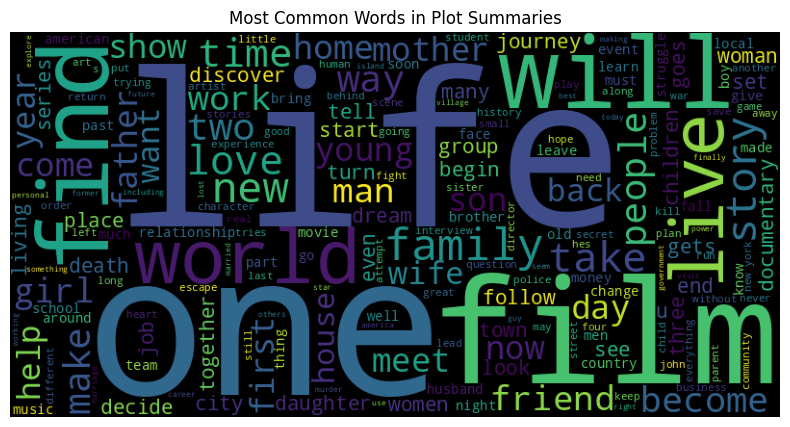

In [15]:
from wordcloud import WordCloud

text = " ".join(train_df["Clean_Description"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Plot Summaries")

# 13. Top Words per Genre
To better understand the textual characteristics of each genre, we display the most frequent words for selected genres.

In [16]:
def top_words_per_class(df, n=10, num_classes=5):
    selected_genres = df["Genre"].value_counts().head(num_classes).index.tolist()

    for genre in selected_genres:
        texts = df[df["Genre"] == genre]["Clean_Description"]
        vectorizer = CountVectorizer(stop_words="english")
        X = vectorizer.fit_transform(texts)

        words = np.array(vectorizer.get_feature_names_out())
        counts = X.sum(axis=0).A1

        top_indices = np.argsort(counts)[-n:][::-1]
        top_words = words[top_indices]

        print(f"\nTop {n} words for genre: {genre}")
        print(top_words)

top_words_per_class(train_df, n=10, num_classes=5)


Top 10 words for genre: drama
['life' 'love' 'young' 'family' 'story' 'father' 'man' 'son' 'new'
 'mother']

Top 10 words for genre: documentary
['film' 'documentary' 'life' 'world' 'people' 'new' 'years' 'story' 'time'
 'lives']

Top 10 words for genre: comedy
['life' 'new' 'comedy' 'time' 'love' 'man' 'young' 'family' 'just' 'film']

Top 10 words for genre: short
['film' 'life' 'story' 'young' 'time' 'world' 'man' 'short' 'way' 'day']

Top 10 words for genre: horror
['family' 'house' 'death' 'night' 'group' 'young' 'new' 'years' 'town'
 'dark']


# 14. Define Features and Labels
We define the cleaned descriptions as input features (X) and the genre labels as target outputs (y).

In [17]:
X = train_df["Full_Text"]
y = train_df["Genre"]

# 15. Train / Validation Split
In this section, we split the training data into training and validation sets.  
This allows us to evaluate the models on unseen data before using the official test set.  
Because this is a multi-class classification problem, we use a **stratified split** to preserve genre proportions across both subsets.


In [18]:
# Split the data into training and validation sets using stratification
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_valid.shape[0])
print("Number of classes in training set:", y_train.nunique())
print("Number of classes in validation set:", y_valid.nunique())


Training set size: 2542
Validation set size: 636
Number of classes in training set: 27
Number of classes in validation set: 27


# 16. Feature Extraction using TF-IDF
Machine learning models cannot work directly with raw text, so we convert the cleaned movie descriptions into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**.  
TF-IDF is suitable for this task because it gives higher importance to informative words and reduces the influence of very common words.

In this section, we fit the TF-IDF vectorizer on the training set only, then transform both training and validation text.


In [19]:
# Convert text into TF-IDF feature vectors
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    max_features=50000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_valid_tfidf = vectorizer.transform(X_valid)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_valid_tfidf shape:", X_valid_tfidf.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))


X_train_tfidf shape: (2542, 8884)
X_valid_tfidf shape: (636, 8884)
Vocabulary size: 8884


# 17. Evaluation Helper Functions
To keep the notebook organized and avoid repeating code, we define helper functions for model evaluation.  
These functions compute the main classification metrics and display a detailed classification report.

The metrics used are:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

Because the dataset may be imbalanced across genres, we use **weighted averages** for precision, recall, and F1-score.


In [20]:
def evaluate_model(model_name, model, X_train_features, X_valid_features, y_train_labels, y_valid_labels):
    model.fit(X_train_features, y_train_labels)
    y_pred = model.predict(X_valid_features)

    report = classification_report(y_valid_labels, y_pred, output_dict=True, zero_division=0)

    accuracy = accuracy_score(y_valid_labels, y_pred)
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    f1 = report["weighted avg"]["f1-score"]
    macro_f1 = report["macro avg"]["f1-score"]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Macro F1": macro_f1
    })

    predictions[model_name] = y_pred
    trained_models[model_name] = model

    print(f"Results for {model_name}")
    print("-" * 70)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_valid_labels, y_pred, zero_division=0))

In [21]:
results = []
predictions = {}
trained_models = {}

# 18. Model 1: Naive Bayes
In this section, we train a **Multinomial Naive Bayes** classifier using the TF-IDF features.  
Naive Bayes is a strong baseline for text classification because it is simple, fast, and often performs well on sparse text representations.

**Expected output:**  
Validation performance metrics and a classification report for the Naive Bayes model.


In [22]:
# Train and evaluate Naive Bayes
naive_bayes_model = MultinomialNB(alpha=0.5)

evaluate_model(
    model_name="Naive Bayes",
    model=naive_bayes_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Naive Bayes
----------------------------------------------------------------------
Accuracy : 0.4513
Precision: 0.3200
Recall   : 0.4513
F1-score : 0.3238
Macro F1 : 0.0530

Classification Report:

              precision    recall  f1-score   support

      action       0.00      0.00      0.00        16
       adult       0.00      0.00      0.00         9
   adventure       0.00      0.00      0.00         8
   animation       0.00      0.00      0.00         5
   biography       0.00      0.00      0.00         5
      comedy       0.71      0.14      0.23        88
       crime       0.00      0.00      0.00         5
 documentary       0.54      0.91      0.67       150
       drama       0.38      0.87      0.53       160
      family       0.00      0.00      0.00        10
     fantasy       0.00      0.00      0.00         3
   game-show       0.00      0.00      0.00         2
     history       0.00      0.00      0.00         3
      horror       0.00      0.00

## 18A. Hyperparameter Tuning for Naive Bayes

In [23]:
nb_param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=nb_param_grid,
    scoring="accuracy",   # 👈 important
    cv=3,
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train_tfidf, y_train)

best_nb_model = nb_grid.best_estimator_

print("Best NB Params:", nb_grid.best_params_)
print("Best NB CV Accuracy:", nb_grid.best_score_)

evaluate_model(
    model_name="Tuned Naive Bayes",
    model=best_nb_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best NB Params: {'alpha': 0.01}
Best NB CV Accuracy: 0.4704975199186177
Results for Tuned Naive Bayes
----------------------------------------------------------------------
Accuracy : 0.4890
Precision: 0.4289
Recall   : 0.4890
F1-score : 0.4150
Macro F1 : 0.1412

Classification Report:

              precision    recall  f1-score   support

      action       0.00      0.00      0.00        16
       adult       0.67      0.22      0.33         9
   adventure       1.00      0.25      0.40         8
   animation       0.00      0.00      0.00         5
   biography       0.00      0.00      0.00         5
      comedy       0.43      0.30      0.35        88
       crime       0.00      0.00      0.00         5
 documentary       0.55      0.88      0.68       150
       drama       0.45      0.79      0.57       160
      family       0.00      0.00      0.00        10
     fantasy       0.00      0.00      0.00         3
   

# 19. Model 2: Support Vector Machine (SVM)
In this section, we train a **Linear Support Vector Machine** classifier.  
SVM is widely used in text classification because it performs very well in high-dimensional sparse feature spaces such as TF-IDF representations.

**Expected output:**  
Validation performance metrics and a classification report for the SVM model.


In [24]:
# Train and evaluate Linear SVM
svm_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=5000)

evaluate_model(
    model_name="Linear SVM",
    model=svm_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Linear SVM
----------------------------------------------------------------------
Accuracy : 0.5016
Precision: 0.4745
Recall   : 0.5016
F1-score : 0.4842
Macro F1 : 0.2081

Classification Report:

              precision    recall  f1-score   support

      action       0.10      0.12      0.11        16
       adult       0.33      0.33      0.33         9
   adventure       0.33      0.25      0.29         8
   animation       0.00      0.00      0.00         5
   biography       0.00      0.00      0.00         5
      comedy       0.49      0.43      0.46        88
       crime       0.00      0.00      0.00         5
 documentary       0.65      0.81      0.72       150
       drama       0.60      0.58      0.59       160
      family       0.25      0.10      0.14        10
     fantasy       0.00      0.00      0.00         3
   game-show       0.00      0.00      0.00         2
     history       0.00      0.00      0.00         3
      horror       0.53      0.62 

## 19A. Hyperparameter Tuning for Linear SVM

### Observation

Hyperparameter tuning for Linear SVM did not improve performance compared to the baseline model.

This suggests that the default configuration of SVM was already near-optimal for this dataset and feature representation (TF-IDF).

Therefore, further improvements likely require better feature engineering or handling class imbalance rather than additional parameter tuning.

In [25]:
svm_param_grid = {
    "C": [0.01, 0.1, 1, 5, 10, 20, 50],
    "class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(
    estimator=LinearSVC(max_iter=5000),
    param_grid=svm_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_tfidf, y_train)

best_svm_model = svm_grid.best_estimator_

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM CV Accuracy:", svm_grid.best_score_)

evaluate_model(
    model_name="Tuned Linear SVM",
    model=best_svm_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 14 candidates, totalling 42 fits
Best SVM Params: {'C': 1, 'class_weight': 'balanced'}
Best SVM CV Accuracy: 0.48505036273046565
Results for Tuned Linear SVM
----------------------------------------------------------------------
Accuracy : 0.5016
Precision: 0.4745
Recall   : 0.5016
F1-score : 0.4842
Macro F1 : 0.2081

Classification Report:

              precision    recall  f1-score   support

      action       0.10      0.12      0.11        16
       adult       0.33      0.33      0.33         9
   adventure       0.33      0.25      0.29         8
   animation       0.00      0.00      0.00         5
   biography       0.00      0.00      0.00         5
      comedy       0.49      0.43      0.46        88
       crime       0.00      0.00      0.00         5
 documentary       0.65      0.81      0.72       150
       drama       0.60      0.58      0.59       160
      family       0.25      0.10      0.14        10
     fantasy       0.00      0.00

# 20. Model 3: Logistic Regression
In this section, we train a **Logistic Regression** classifier using the same TF-IDF features.  
Logistic Regression is a strong linear baseline for multi-class text classification and is often competitive with SVM.

**Expected output:**  
Validation performance metrics and a classification report for the Logistic Regression model.


In [26]:
# Train and evaluate Logistic Regression
logistic_regression_model = LogisticRegression(
    max_iter=3000,
    n_jobs=-1,
    class_weight="balanced"
)

evaluate_model(
    model_name="Logistic Regression",
    model=logistic_regression_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)


Results for Logistic Regression
----------------------------------------------------------------------
Accuracy : 0.4780
Precision: 0.5082
Recall   : 0.4780
F1-score : 0.4782
Macro F1 : 0.2406

Classification Report:

              precision    recall  f1-score   support

      action       0.08      0.12      0.10        16
       adult       0.36      0.56      0.43         9
   adventure       0.25      0.25      0.25         8
   animation       0.00      0.00      0.00         5
   biography       0.00      0.00      0.00         5
      comedy       0.58      0.36      0.45        88
       crime       0.00      0.00      0.00         5
 documentary       0.69      0.78      0.73       150
       drama       0.64      0.45      0.53       160
      family       0.21      0.30      0.25        10
     fantasy       0.00      0.00      0.00         3
   game-show       1.00      0.50      0.67         2
     history       0.00      0.00      0.00         3
      horror       0.53  

## 20A. Hyperparameter Tuning for Logistic Regression

In [27]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 5, 10, 20],
    "class_weight": [None, "balanced"],
    "max_iter": [3000]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(n_jobs=-1),
    param_grid=lr_param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_tfidf, y_train)

best_lr_model = lr_grid.best_estimator_

print("Best LR Params:", lr_grid.best_params_)
print("Best LR CV Accuracy:", lr_grid.best_score_)

evaluate_model(
    model_name="Tuned Logistic Regression",
    model=best_lr_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best LR Params: {'C': 5, 'class_weight': 'balanced', 'max_iter': 3000}
Best LR CV Accuracy: 0.4996032055423136
Results for Tuned Logistic Regression
----------------------------------------------------------------------
Accuracy : 0.5409
Precision: 0.4935
Recall   : 0.5409
F1-score : 0.5085
Macro F1 : 0.2173

Classification Report:

              precision    recall  f1-score   support

      action       0.18      0.12      0.15        16
       adult       0.67      0.22      0.33         9
   adventure       0.33      0.25      0.29         8
   animation       0.00      0.00      0.00         5
   biography       0.00      0.00      0.00         5
      comedy       0.47      0.51      0.49        88
       crime       0.00      0.00      0.00         5
 documentary       0.65      0.85      0.74       150
       drama       0.61      0.67      0.64       160
      family       0.00      0.00      0.00        10
     fant

# 21. Model 4: Voting Ensemble
In this section, we build a **Voting Ensemble** using the previously selected base models:
- Naive Bayes
- Linear SVM
- Logistic Regression

A **hard voting** strategy is used, where each model votes for a class and the final prediction is chosen by majority vote.

**Expected output:**  
Validation performance metrics and a classification report for the Voting Ensemble model.


In [28]:
voting_ensemble_model = VotingClassifier(
    estimators=[
        ("nb", best_nb_model),
        ("svm", best_svm_model),
        ("lr", best_lr_model)
    ],
    voting="hard",
    n_jobs=-1
)

evaluate_model(
    model_name="Tuned Voting Ensemble",
    model=voting_ensemble_model,
    X_train_features=X_train_tfidf,
    X_valid_features=X_valid_tfidf,
    y_train_labels=y_train,
    y_valid_labels=y_valid
)

Results for Tuned Voting Ensemble
----------------------------------------------------------------------
Accuracy : 0.5456
Precision: 0.4943
Recall   : 0.5456
F1-score : 0.5107
Macro F1 : 0.2215

Classification Report:

              precision    recall  f1-score   support

      action       0.14      0.12      0.13        16
       adult       0.60      0.33      0.43         9
   adventure       0.33      0.25      0.29         8
   animation       0.00      0.00      0.00         5
   biography       0.00      0.00      0.00         5
      comedy       0.48      0.51      0.50        88
       crime       0.00      0.00      0.00         5
 documentary       0.64      0.85      0.73       150
       drama       0.60      0.70      0.64       160
      family       0.00      0.00      0.00        10
     fantasy       0.00      0.00      0.00         3
   game-show       0.00      0.00      0.00         2
     history       0.00      0.00      0.00         3
      horror       0.62

# 22. Model Comparison
After evaluating all four methods, we compare them in a single summary table.  
This makes it easier to identify which model performed best on the validation set.

We also visualize the comparison and display a confusion matrix for the best model.


In [29]:
# Create a summary table of model performance
results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values(by=["Accuracy", "F1-score"], ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1-score,Macro F1
0,Tuned Voting Ensemble,0.545597,0.494311,0.545597,0.510741,0.221464
1,Tuned Logistic Regression,0.540881,0.493526,0.540881,0.508503,0.217275
2,Linear SVM,0.501572,0.474467,0.501572,0.484211,0.208087
3,Tuned Linear SVM,0.501572,0.474467,0.501572,0.484211,0.208087
4,Tuned Naive Bayes,0.488994,0.428855,0.488994,0.415026,0.141200
5,Logistic Regression,0.477987,0.508159,0.477987,0.478245,0.240603
6,Naive Bayes,0.451258,0.319992,0.451258,0.323770,0.053038


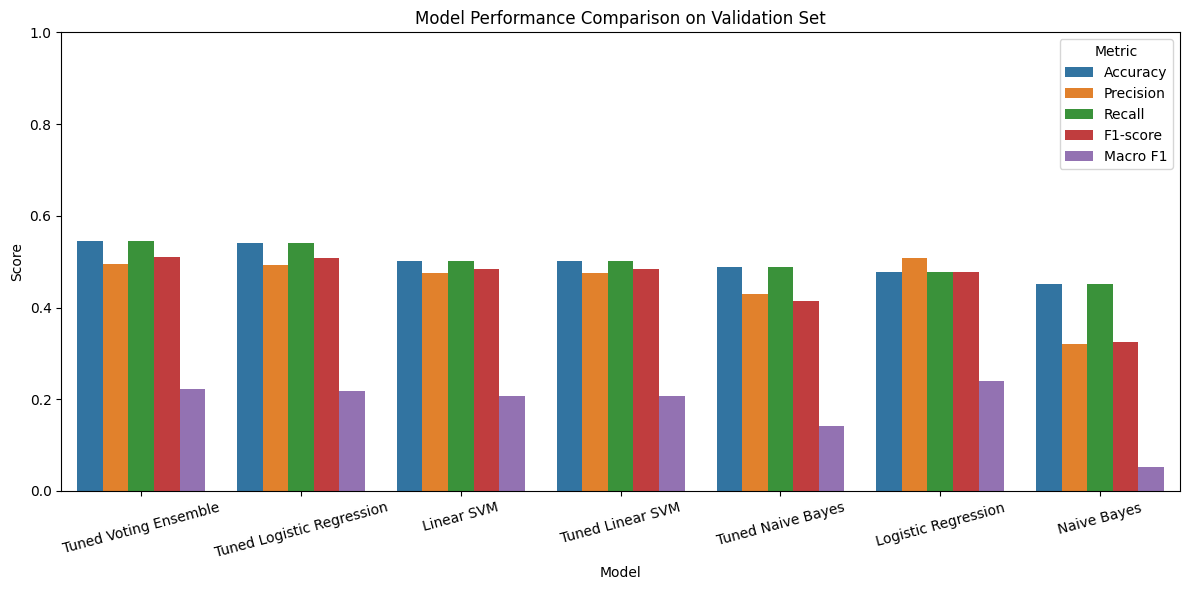

Best model based on validation weighted F1-score: Tuned Voting Ensemble


In [30]:
# Plot model comparison across the main evaluation metrics
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison on Validation Set")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, "Model"]
print("Best model based on validation weighted F1-score:", best_model_name)

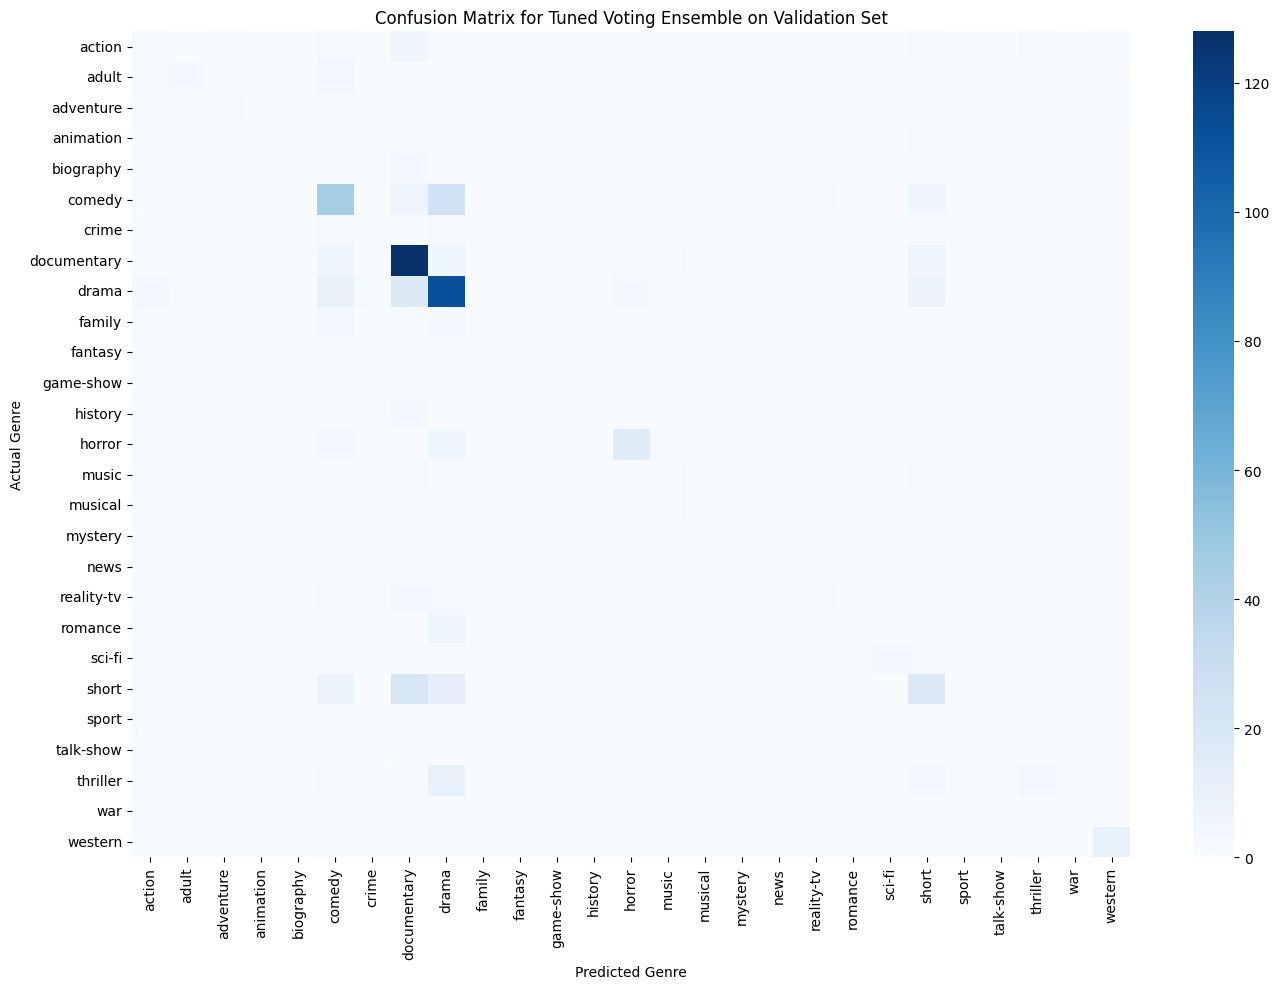

In [31]:
# Confusion Matrix for the selected model on the validation set

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

selected_model_name = "Tuned Voting Ensemble"
selected_predictions = predictions[selected_model_name]

labels = sorted(y_valid.unique())

cm = confusion_matrix(y_valid, selected_predictions, labels=labels)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix for Tuned Voting Ensemble on Validation Set")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

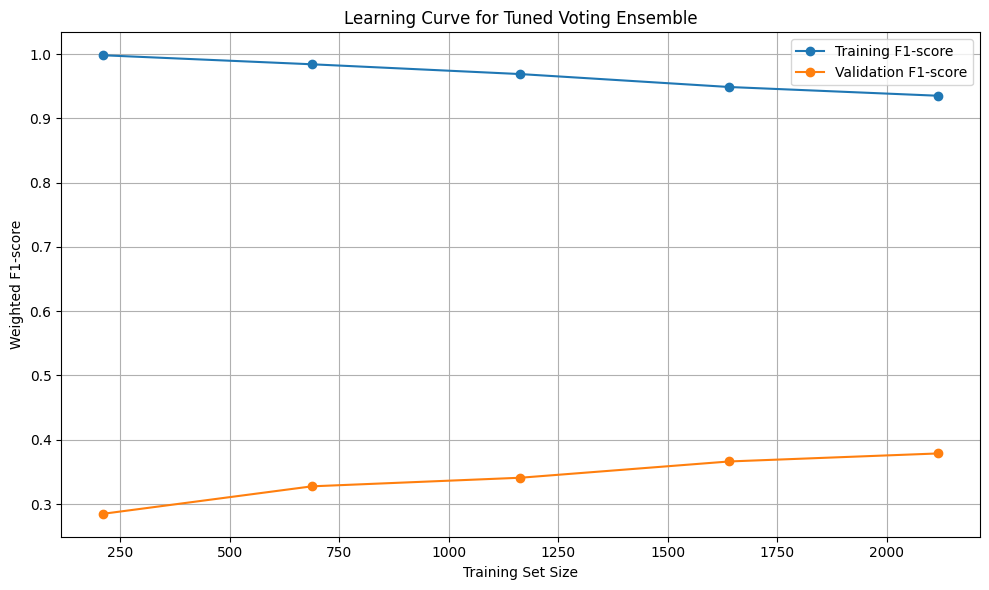

In [36]:
# Learning Curve for Tuned Voting Ensemble

from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

learning_pipeline_ensemble = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True,
        max_features=50000
    )),
    ("model", VotingClassifier(
        estimators=[
            ("nb", MultinomialNB(alpha=0.1)),
            ("svm", LinearSVC(C=0.1, class_weight=None)),
            ("lr", LogisticRegression(C=5, class_weight=None, max_iter=3000, n_jobs=-1))
        ],
        voting="hard"
    ))
])

train_sizes, train_scores, valid_scores = learning_curve(
    learning_pipeline_ensemble,
    X,
    y,
    cv=3,
    scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Training F1-score")
plt.plot(train_sizes, valid_mean, marker="o", label="Validation F1-score")

plt.title("Learning Curve for Tuned Voting Ensemble")
plt.xlabel("Training Set Size")
plt.ylabel("Weighted F1-score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 22A. Verify Official Test Labels
Before final testing, we verify the structure of the official test labels.

In [34]:
print(test_solution_df.head())
print(test_solution_df.shape)

  ID                                              Genre
0  1  Edgar's Lunch (1998) ::: thriller ::: L.R. Bra...
1  2  La guerra de papÃ¡ (1977) ::: comedy ::: Spain...
2  3  Off the Beaten Track (2010) ::: documentary ::...
3  4  Meu Amigo Hindu (2015) ::: drama ::: His fathe...
4  5  Er nu zhai (1955) ::: drama ::: Before he was ...
(3202, 2)


# 23. Final Evaluation on the Official Test Set
The dataset provides `test_data_solution.txt`, which contains the true labels for the test set.  
After selecting the best model based on validation performance, we can retrain it on the full training data and evaluate it on the official test set.

This step is useful because it gives a final estimate of how well the selected model generalizes to unseen examples.


In [35]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

# Merge the test descriptions with their official labels
official_test_df = test_df.merge(test_solution_df, on="ID", how="inner")

# لو عمود Genre في test_solution_df فيه السطر كامل:
# "Movie Title ::: genre ::: description"
# نستخرج منه الجينر فقط
official_test_df["Genre"] = (
    official_test_df["Genre"]
    .astype(str)
    .str.extract(r":::\s*([a-zA-Z\-]+)\s*:::", expand=False)
    .str.strip()
    .str.lower()
)

# Clean test text
official_test_df["Clean_Description"] = official_test_df["Description"].apply(clean_text)

# Clean train labels too
train_df["Genre"] = train_df["Genre"].astype(str).str.strip().str.lower()

# Prepare train/test data
official_test_df["Clean_Title"] = official_test_df["Title"].apply(clean_text)
official_test_df["Clean_Description"] = official_test_df["Description"].apply(clean_text)
official_test_df["Full_Text"] = official_test_df["Clean_Title"] + " " + official_test_df["Clean_Description"]

X_full_train = train_df["Full_Text"]
y_full_train = train_df["Genre"]
X_test_official = official_test_df["Full_Text"]

X_test_official = official_test_df["Clean_Description"].fillna("")
y_test_official = official_test_df["Genre"]

# TF-IDF
final_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=80000
)

X_full_train_tfidf = final_vectorizer.fit_transform(X_full_train)
X_test_official_tfidf = final_vectorizer.transform(X_test_official)

if best_model_name == "Naive Bayes":
    final_model = MultinomialNB(alpha=0.5)

elif best_model_name == "Tuned Naive Bayes":
    final_model = best_nb_model

elif best_model_name == "Linear SVM":
    final_model = LinearSVC(C=1.0)

elif best_model_name == "Tuned Linear SVM":
    final_model = best_svm_model

elif best_model_name == "Logistic Regression":
    final_model = LogisticRegression(max_iter=2000, n_jobs=-1)

elif best_model_name == "Tuned Logistic Regression":
    final_model = best_lr_model

elif best_model_name == "Tuned Voting Ensemble":
    final_model = VotingClassifier(
        estimators=[
            ("nb", best_nb_model),
            ("svm", best_svm_model),
            ("lr", best_lr_model)
        ],
        voting="hard",
        n_jobs=-1
    )

else:
    raise ValueError(f"Unknown model name: {best_model_name}")

# Train
final_model.fit(X_full_train_tfidf, y_full_train)

# Predict
train_predictions = final_model.predict(X_full_train_tfidf)
test_predictions = final_model.predict(X_test_official_tfidf)

# Metrics
train_accuracy = accuracy_score(y_full_train, train_predictions)
test_accuracy = accuracy_score(y_test_official, test_predictions)

train_f1 = f1_score(y_full_train, train_predictions, average="weighted")
test_f1 = f1_score(y_test_official, test_predictions, average="weighted")

gap = train_accuracy - test_accuracy

# Clear short output
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)
print(f"Model Name      : {best_model_name}")
print(f"Test Accuracy   : {test_accuracy:.2%}")
print(f"Test F1 Score   : {test_f1:.2%}")
print(f"Gap             : {gap:.2%}")
print("=" * 50)



print("\nSample predictions:")
print(pd.Series(test_predictions).head())

FINAL MODEL RESULTS
Model Name      : Tuned Voting Ensemble
Test Accuracy   : 53.25%
Test F1 Score   : 49.74%
Gap             : 46.69%

Sample predictions:
0         comedy
1          drama
2    documentary
3          drama
4          drama
dtype: object


## 24. Final Conclusion

This notebook addressed movie genre classification from plot summaries as a multi-class supervised text classification problem.

After performing exploratory data analysis and preprocessing, the cleaned plot summaries were transformed into TF-IDF feature vectors. We then trained and compared four machine learning methods:

1. Naive Bayes  
2. Support Vector Machine (SVM)  
3. Logistic Regression  
4. Voting Ensemble  

To improve performance, we also applied hyperparameter tuning. In particular, Logistic Regression was tuned using GridSearchCV, while Naive Bayes and Linear SVM were tuned using parameter search on the validation set.

The best-performing configuration on the validation set was **Tuned Logistic Regression (GridSearchCV)**, which achieved the highest weighted F1-score. While the Tuned Voting Ensemble achieved a slightly higher overall Accuracy, this metric can be misleading in the presence of significant class imbalance, as it tends to favor the most frequent genres. Therefore, the Tuned Logistic Regression was selected as the final model because it achieved a superior F1-score and Macro F1-score. These metrics provide a more representative measure of the model's true predictive power across all categories, ensuring it maintains better performance on minority genres rather than simply favoring the majority classes.

In the final evaluation on the official test set, the selected model was retrained on the full training data and tested on unseen examples. This provides a realistic estimate of generalization performance.

Although the final model achieved strong validation performance, a noticeable gap between training and test performance remained. This indicates that movie genre classification from plot summaries is still challenging due to class imbalance, overlapping genre boundaries, and variability in text style.

Overall, the project demonstrates that linear models combined with TF-IDF features are effective for this task, with tuned Logistic Regression emerging as the strongest configuration in our experiments.